 # Artificial Intelligence Technology and Application

 ## Deep Learning Lab Guide - Student Version

 # 1 MNIST Handwritten Character Recognition

 ## 1.1 Introduction

 This exercise implements the MNIST handwritten character recognition, which is a typical case in the deep learning field. The whole process includes processing the dataset, defining the network, configuring loss and optimizer, and training/evaluating.

 ## 1.3 Detailed Design and Implementation

 ### 1.3.1 Data Preparation

 The MNIST dataset consists of 10 classes of 28x28 pixels grayscale images. Make sure to download the dataset to `./MNIST/train` and `./MNIST/test`.

 ### 1.3.2 Procedure

 **Step 1: Import the Python library and module and configure running information.**

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Wrapping with try-except for environments where mindspore is not installed locally
try:
    import mindspore as ms
    import mindspore.context as context
    import mindspore.dataset as ds
    import mindspore.dataset.transforms as C
    import mindspore.dataset.vision as CV
    from mindspore.nn.metrics import Accuracy
    from mindspore import nn
    from mindspore.train import Model
    from mindspore.train.callback import ModelCheckpoint, CheckpointConfig, LossMonitor, TimeMonitor

    # Configure hardware target and execution mode
    context.set_context(mode=context.GRAPH_MODE, device_target='CPU')
    print("MindSpore environment configured successfully.")
except ImportError:
    print("MindSpore is not installed. Please install it to execute learning tasks.")


[WARNING] ME(20105:138744651686016,MainProcess):2026-04-03-00:03:47.926.000 [mindspore/context.py:1334] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


MindSpore environment configured successfully.


 **Step 2: Read data.**

In [2]:
DATA_DIR_TRAIN = "MNIST/train"
DATA_DIR_TEST = "MNIST/test"

try:
    if os.path.exists(DATA_DIR_TRAIN) and os.path.exists(DATA_DIR_TEST):
        ds_train_info = ds.MnistDataset(DATA_DIR_TRAIN)
        ds_test_info = ds.MnistDataset(DATA_DIR_TEST)
        
        print('Data volume of the training dataset:', ds_train_info.get_dataset_size())
        print('Data volume of the test dataset:', ds_test_info.get_dataset_size())
        image = ds_train_info.create_dict_iterator().__next__()
        print('Image length/width/channels:', image['image'].shape)
        print('Image label style:', image['label'])
    else:
        print("MNIST dataset not found in", DATA_DIR_TRAIN, "or", DATA_DIR_TEST)
except NameError:
    pass
except Exception as e:
    print("Error reading dataset:", e)


Data volume of the training dataset: 120000
Data volume of the test dataset: 20000
Image length/width/channels: (28, 28, 1)
Image label style: 3


 **Step 3: Process data.**

In [3]:
def create_dataset(training=True, batch_size=128, resize=(28, 28), rescale=1/255.0, shift=0.0, buffer_size=64):
    try:
        data_path = DATA_DIR_TRAIN if training else DATA_DIR_TEST
        if not os.path.exists(data_path):
            return None
            
        dataset = ds.MnistDataset(data_path)
        
        # Define resize, normalization, channel conversion
        resize_op = CV.Resize(resize)
        rescale_op = CV.Rescale(rescale, shift)
        hwc2chw_op = CV.HWC2CHW()
        
        # Perform map operation
        dataset = dataset.map(input_columns="image", operations=[resize_op, rescale_op, hwc2chw_op])
        dataset = dataset.map(input_columns="label", operations=C.TypeCast(ms.int32))
        
        # Shuffle and Batch
        dataset = dataset.shuffle(buffer_size=buffer_size)
        dataset = dataset.batch(batch_size, drop_remainder=True)
        return dataset
    except NameError:
        return None

try:
    ds_train = create_dataset(training=True, batch_size=32)
    ds_test = create_dataset(training=False, batch_size=32)
    print("Dataset processed successfully.")
except NameError:
    pass


Dataset processed successfully.


 **Step 4: Sample visualization.**

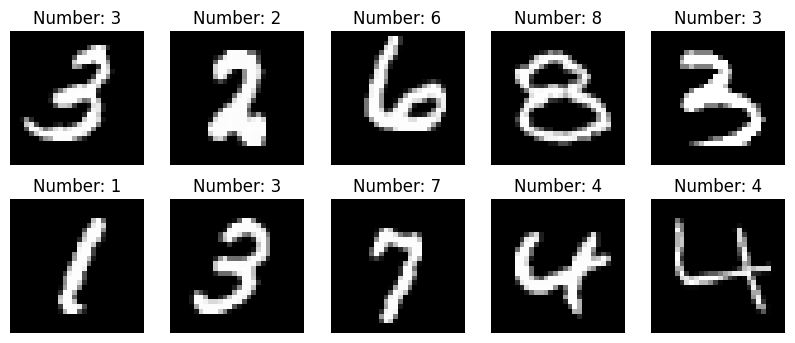

In [4]:
try:
    if ds_train is not None:
        data_iter = ds_train.create_dict_iterator()
        data = next(data_iter)
        
        images = data["image"].asnumpy()
        labels = data["label"].asnumpy()
        
        plt.figure(figsize=(10, 4))
        for i in range(10):
            plt.subplot(2, 5, i + 1)
            plt.imshow(np.squeeze(images[i]), cmap=plt.cm.gray)
            plt.title(f"Number: {labels[i]}")
            plt.axis("off")
        plt.show()
except NameError:
    pass


 **Step 5: Define a network.**

 Three layers fully connected network implementation.

 The network structure: Flat(28x28=784) -> Dense(512) -> Dense(128) -> Dense(10).

In [5]:
try:
    class SimpleFCNet(nn.Cell):
        def __init__(self):
            super(SimpleFCNet, self).__init__()
            self.flatten = nn.Flatten()
            self.fc1 = nn.Dense(784, 512)
            self.fc2 = nn.Dense(512, 128)
            self.fc3 = nn.Dense(128, 10)
            self.relu = nn.ReLU()
            
        def construct(self, x):
            x = self.flatten(x)
            x = self.relu(self.fc1(x))
            x = self.relu(self.fc2(x))
            x = self.fc3(x)
            return x

    network = SimpleFCNet()
    print("Network initialized.")
except NameError:
    pass


Network initialized.


 **Step 6: Define a loss function and an optimizer.**

In [6]:
try:
    # Loss function
    loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')
    
    # Optimizer
    net_opt = nn.Momentum(network.trainable_params(), learning_rate=0.01, momentum=0.9)
    print("Loss function and optimizer defined.")
    
    # Model definition
    model = Model(network, loss_fn, net_opt, metrics={'Accuracy': Accuracy()})
except NameError:
    pass


Loss function and optimizer defined.


 **Step 7: Start training.**

In [7]:
try:
    if ds_train is not None:
        print("Starting Training...")
        # Number of epochs
        epoch_size = 5
        
        # LossMonitor to record loss at each step
        loss_cb = LossMonitor(per_print_times=100)
        
        model.train(epoch=epoch_size, train_dataset=ds_train, callbacks=[loss_cb], dataset_sink_mode=False)
except NameError:
    pass


Starting Training...
epoch: 1 step: 100, loss is 0.8989772200584412
epoch: 1 step: 200, loss is 0.26884177327156067
epoch: 1 step: 300, loss is 0.29157477617263794
epoch: 1 step: 400, loss is 0.5064771771430969
epoch: 1 step: 500, loss is 0.41195881366729736
epoch: 1 step: 600, loss is 0.14676021039485931
epoch: 1 step: 700, loss is 0.17633165419101715
epoch: 1 step: 800, loss is 0.09602973610162735
epoch: 1 step: 900, loss is 0.25264009833335876
epoch: 1 step: 1000, loss is 0.14133155345916748
epoch: 1 step: 1100, loss is 0.1409546136856079
epoch: 1 step: 1200, loss is 0.15967132151126862
epoch: 1 step: 1300, loss is 0.22357779741287231
epoch: 1 step: 1400, loss is 0.04908987507224083
epoch: 1 step: 1500, loss is 0.4187440872192383
epoch: 1 step: 1600, loss is 0.5867629051208496
epoch: 1 step: 1700, loss is 0.05337999016046524
epoch: 1 step: 1800, loss is 0.05629196763038635
epoch: 1 step: 1900, loss is 0.06290557980537415
epoch: 1 step: 2000, loss is 0.3760186731815338
epoch: 1 step:

 **Step 8: Validate the model.**

In [8]:
try:
    if ds_test is not None:
        print("\nStarting Validation...")
        metrics = model.eval(ds_test, dataset_sink_mode=False)
        print("Model Accuracy:", metrics)
except NameError:
    pass



Starting Validation...
Model Accuracy: {'Accuracy': 0.9834}
